In [17]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             mean_squared_error, r2_score)

#Wczytanie danych

df = pd.read_csv('complications.csv')

#Zmiana pustych wartości (np. spacji) na NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

#Wybranie podzbioru kolumn
#M.in. wiek, płeć, ciśnienie, potas (K_BLOOD), leukocyty (L_BLOOD)
cols_to_keep =['AGE', 'SEX', 'S_AD_KBRIG', 'D_AD_KBRIG', 'K_BLOOD', 'L_BLOOD', 'LET_IS']
df = df[cols_to_keep].copy()

#Konwersja na typ numeryczny w celu usunięcia ewentualnych problemów z formatowaniem
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Przykładowe dane:")
display(df.head())



Przykładowe dane:


,AGE,SEX,S_AD_KBRIG,D_AD_KBRIG,K_BLOOD,L_BLOOD,LET_IS
0,77.0,1,NaN,NaN,4.7,8.0,0
1,55.0,1,NaN,NaN,3.5,7.8,0
2,52.0,1,150.0,100.0,4.0,10.8,0
3,68.0,0,NaN,NaN,3.9,NaN,0
4,60.0,1,190.0,100.0,3.5,8.3,0



Klasyfikacja
Raport:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       357
           1       0.57      0.12      0.20        68

    accuracy                           0.84       425
   macro avg       0.71      0.55      0.55       425
weighted avg       0.81      0.84      0.80       425

Accuracy: 0.845
Precision: 0.571
Recall: 0.118
F1-score: 0.195
ROC AUC: 0.735


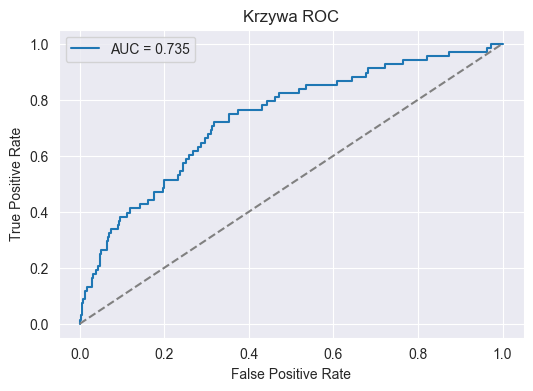

In [18]:
print("\nKlasyfikacja")

#Odrzucamy wiersze, które nie mają zmiennej docelowej dla klasyfikacji
df_clf = df.dropna(subset=['LET_IS']).copy()

#Binarizacja zmiennej docelowej
y_clf = (df_clf['LET_IS'] > 0).astype(int)
X_clf = df_clf.drop(columns=['LET_IS'])

#Podział na zbiór treningowy i testowy
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

#Pipeline preprocessing (Standaryzacja numerycznych i OneHot dla kategorycznych)
numeric_features_c =['AGE', 'S_AD_KBRIG', 'D_AD_KBRIG', 'K_BLOOD', 'L_BLOOD']
categorical_features_c = ['SEX']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_clf = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features_c),
    ('cat', categorical_transformer, categorical_features_c)
])

#Budowa modelu
model_clf = Pipeline(steps=[
    ('prep', preprocessor_clf),
    ('clf', LogisticRegression(max_iter=1000))
])

#Trenowanie
model_clf.fit(X_train_c, y_train_c)

#Ewaluacja i przewidywania
y_pred_c = model_clf.predict(X_test_c)
y_proba_c = model_clf.predict_proba(X_test_c)[:, 1]

print("Raport:")
print(classification_report(y_test_c, y_pred_c))

#Miary
print(f"Accuracy: {accuracy_score(y_test_c, y_pred_c):.3f}")
print(f"Precision: {precision_score(y_test_c, y_pred_c, zero_division=0):.3f}")
print(f"Recall: {recall_score(y_test_c, y_pred_c, zero_division=0):.3f}")
print(f"F1-score: {f1_score(y_test_c, y_pred_c, zero_division=0):.3f}")
print(f"ROC AUC: {roc_auc_score(y_test_c, y_proba_c):.3f}")

#Wykres krzywej ROC
fpr, tpr, thr = roc_curve(y_test_c, y_proba_c)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_c, y_proba_c):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC")
plt.legend()
plt.show()


Regresja Liniowa
RMSE: 19.23
R^2:  0.709


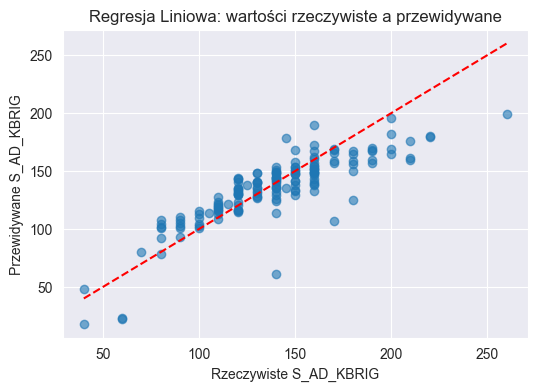

In [19]:
print("\nRegresja Liniowa")


df_reg = df.dropna(subset=['S_AD_KBRIG']).copy()

#Zmienne objaśniające i zmienna docelowa
X_reg = df_reg.drop(columns=['S_AD_KBRIG', 'LET_IS'])
y_reg = df_reg['S_AD_KBRIG']

#Podział danych
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

numeric_features_r =['AGE', 'D_AD_KBRIG', 'K_BLOOD', 'L_BLOOD']
categorical_features_r = ['SEX']

preprocessor_reg = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features_r),
    ('cat', categorical_transformer, categorical_features_r)
])

#Budowa modelu
model_reg = Pipeline(steps=[
    ('prep', preprocessor_reg),
    ('reg', LinearRegression())
])

#Trenowanie
model_reg.fit(X_train_r, y_train_r)

#Przewidywanie
y_pred_r = model_reg.predict(X_test_r)

#Ocena RMSE oraz R^2
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)
print(f"RMSE: {rmse:.2f}")
print(f"R^2:  {r2:.3f}")

#Wykres zaleznosci: przewidywania vs rzeczywiste wartości
plt.figure(figsize=(6,4))
plt.scatter(y_test_r, y_pred_r, alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()],[y_test_r.min(), y_test_r.max()], 'r--')
plt.xlabel("Rzeczywiste S_AD_KBRIG")
plt.ylabel("Przewidywane S_AD_KBRIG")
plt.title("Regresja Liniowa: wartości rzeczywiste a przewidywane")
plt.show()


SIEC CNN


C:\Users\Admin\PycharmProjects\IRWZM\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dokładność CNN na zbiorze testowym: 1.000


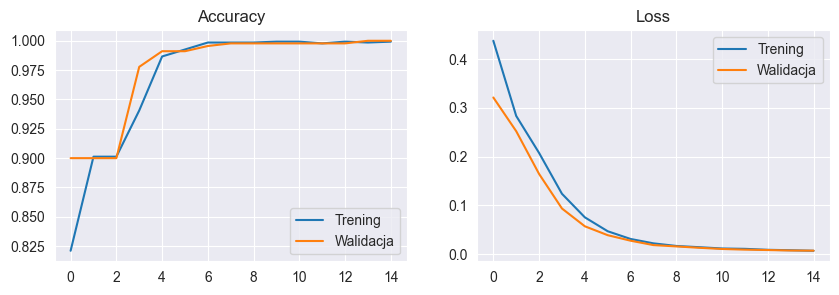

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
import tensorflow as tf
from tensorflow.keras import layers, models

print("\nSIEC CNN")

#Wczytanie wbudowanych obrazów i konwersja na problem binarny
digits = load_digits()
X_img = digits.images.astype("float32") / 16.0
X_img = np.expand_dims(X_img, axis=-1)

#cyfra 0 to "zdrowe" (klasa 0), a wszystko inne to "chore" (klasa 1)
y_img_binary = (digits.target > 0).astype(int)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_img, y_img_binary, test_size=0.25, random_state=42, stratify=y_img_binary
)

#Prosta sieć CNN dla obrazów 8x8
model_cnn = models.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(8, 8, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') #sigmoid dla klasyfikacji binarnej
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model_cnn.fit(X_train_i, y_train_i, epochs=15, validation_data=(X_test_i, y_test_i), verbose=0)

test_loss, test_acc = model_cnn.evaluate(X_test_i, y_test_i, verbose=0)
print(f"Dokładność CNN na zbiorze testowym: {test_acc:.3f}")

#Rysowanie wykresów
plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Trening')
plt.plot(history.history['val_accuracy'], label='Walidacja')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Trening')
plt.plot(history.history['val_loss'], label='Walidacja')
plt.title('Loss')
plt.legend()
plt.show()